## A/B Test Analysis: Impact of Gate Placement on Player Engagement and Retention

### Objective

This analysis evaluates an A/B experiment conducted on the mobile game *Cookie Cats*. The experiment compares two versions of the game:

* **Control (`gate_30`)** — the progression gate is placed at level 30.
* **Treatment (`gate_40`)** — the progression gate is moved to level 40.

The objective is to determine whether changing the position of the progression gate affects player behaviour.

The analysis focuses on three primary research questions:

1. Does changing the gate position affect overall player engagement, measured by the number of game rounds played?
2. Does changing the gate position affect short-term player retention?
3. Does changing the gate position affect longer-term player retention?

An additional exploratory analysis examines the relationship between player engagement and retention across both experiment variants.


In [6]:
import pandas as pd

In [7]:
df = pd.read_csv('cookie_cats.csv');
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [8]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [9]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Data Understanding and Cleaning

The dataset was first examined to understand its structure, variable types, completeness, and overall distribution. Checks were performed for missing values and duplicate observations to identify potential data-quality issues before conducting the experiment analysis.

The key variables used in this study are:

* `userid` — unique identifier for each player.
* `version` — experiment group assigned to the player (`gate_30` or `gate_40`).
* `sum_gamerounds` — total number of game rounds played.
* `retention_1` — whether the player returned one day after installation.
* `retention_7` — whether the player returned seven days after installation.

The distribution of `sum_gamerounds` was also examined for extreme observations. Extremely large values can disproportionately influence mean-based engagement statistics and visualizations. The cleaned dataset used for subsequent analysis retains observations with game rounds between 0 and 3,000.

This filtering decision should be considered when interpreting the engagement results, as it excludes exceptionally high-activity players.


In [17]:
test_skew = df[(df['sum_gamerounds'] > 2000)]

In [18]:
test_skew.head()

,userid,version,sum_gamerounds,retention_1,retention_7
6536,725080,gate_40,2015,True,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
36933,4090246,gate_40,2124,True,True
43671,4832608,gate_30,2438,True,True


In [19]:
test_skew.value_counts()

userid   version  sum_gamerounds  retention_1  retention_7
725080   gate_40  2015            True         True           1
871500   gate_30  2961            True         True           1
3271615  gate_40  2640            True         False          1
4090246  gate_40  2124            True         True           1
4832608  gate_30  2438            True         True           1
5133952  gate_30  2251            True         True           1
5346171  gate_40  2294            True         True           1
6390605  gate_30  49854           False        True           1
9640085  gate_30  2156            True         True           1
9791599  gate_40  2063            True         True           1
Name: count, dtype: int64

In [51]:
cookie_data = df[(df['sum_gamerounds'] >= 0) & (df['sum_gamerounds'] <= 3000)].copy()

In [21]:
cookie_data.to_csv('cleaned_data.csv', index=False)

In [22]:
cookie_data['version'].value_counts()

version
gate_40    45489
gate_30    44699
Name: count, dtype: int64

## Experimental Group Distribution

Before comparing outcomes, the distribution of users across the two experimental groups was examined.

The purpose of this step is to confirm that the sample is reasonably balanced between the control and treatment variants. A substantial imbalance could require further investigation before comparing experiment outcomes.

The resulting distribution shows that users are approximately evenly divided between `gate_30` and `gate_40`, providing comparable sample sizes for subsequent analysis.


In [23]:
cookie_data['version'].value_counts(normalize=True) * 100

version
gate_40    50.437974
gate_30    49.562026
Name: proportion, dtype: float64

In [24]:
cookie_data.groupby('version').agg(
    users=('userid', 'count'),
    avg_rounds=('sum_gamerounds', 'mean'),
    median_rounds=('sum_gamerounds', 'median'),
    day1_retention=('retention_1', 'mean'),
    day7_retention=('retention_7', 'mean')
)

,users,avg_rounds,median_rounds,day1_retention,day7_retention
version,,,,,
gate_30,44699,51.342111,17.0,0.448198,0.190183
gate_40,45489,51.298776,16.0,0.442283,0.182000


In [25]:
cookie_data.groupby('version')['sum_gamerounds'].describe()

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44699.0,51.342111,102.057598,0.0,5.0,17.0,50.0,2961.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


In [26]:
cookie_data.groupby('version')['sum_gamerounds'].describe()

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44699.0,51.342111,102.057598,0.0,5.0,17.0,50.0,2961.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


In [27]:
cookie_data.groupby('version')['sum_gamerounds'].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

,mean,median,std,min,max
version,,,,,
gate_30,51.342111,17.0,102.057598,0,2961
gate_40,51.298776,16.0,103.294416,0,2640


## Analysis 1: Effect of Gate Placement on Player Engagement

The first research question examines whether moving the progression gate from level 30 to level 40 affected overall player engagement.

Player engagement is represented by `sum_gamerounds`, which measures the total number of game rounds played by each user.

### Hypotheses

**Null hypothesis (H₀):** There is no difference in player engagement between users assigned to `gate_30` and `gate_40`.

**Alternative hypothesis (H₁):** Player engagement differs between users assigned to `gate_30` and `gate_40`.

Both mean and median game rounds were examined because the distribution of game rounds is skewed and contains high-activity players. The box plot further illustrates the distribution of engagement across both experiment groups.

The descriptive results suggest that overall engagement behaviour is broadly similar between the two variants. A formal statistical test would be required to determine whether any observed difference in game rounds is statistically significant.


In [29]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [30]:
import matplotlib.pyplot as plt

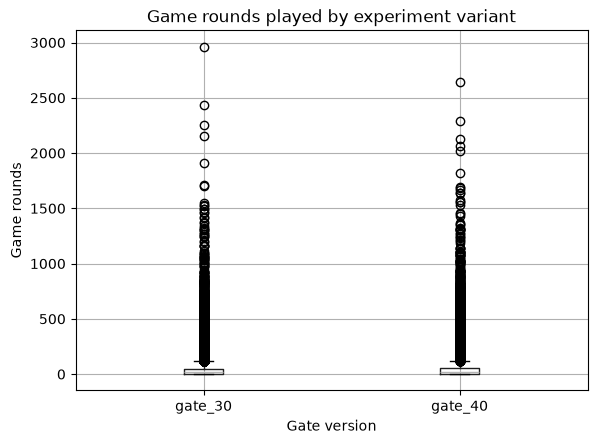

In [31]:
import matplotlib.pyplot as plt

cookie_data.boxplot(
    column='sum_gamerounds',
    by='version'
)

plt.title('Game rounds played by experiment variant')
plt.suptitle('')
plt.xlabel('Gate version')
plt.ylabel('Game rounds')
plt.show()

In [70]:
day1 = cookie_data.groupby('version')['retention_1'].mean()

print(day1 * 100)

version
gate_30    44.819795
gate_40    44.228275
Name: retention_1, dtype: float64


In [71]:
day1_effect = (
    day1['gate_40']
    - day1['gate_30']
)

print(
    'Treatment effect:',
    day1_effect * 100,
    'percentage points'
)

Treatment effect: -0.5915196587034155 percentage points


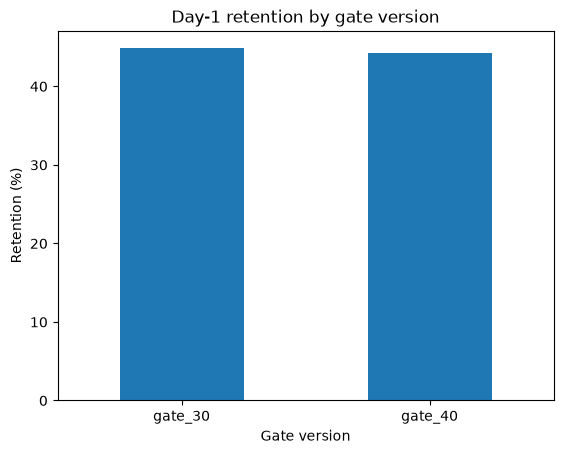

In [72]:
(day1 * 100).plot(kind='bar')

plt.title('Day-1 retention by gate version')
plt.xlabel('Gate version')
plt.ylabel('Retention (%)')
plt.xticks(rotation=0)
plt.show()

In [32]:
day7 = cookie_data.groupby('version')['retention_7'].mean()

print(day7 * 100)

version
gate_30    19.018323
gate_40    18.200004
Name: retention_7, dtype: float64


In [33]:
day7_effect = (
    day7['gate_40']
    - day7['gate_30']
)

print(
    'Treatment effect:',
    day7_effect * 100,
    'percentage points'
)

Treatment effect: -0.818318160884296 percentage points


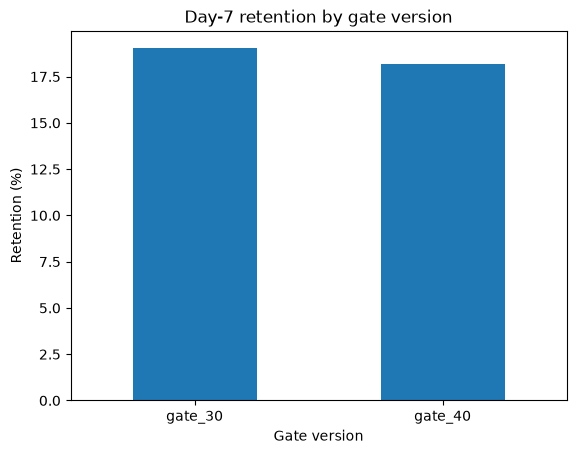

In [34]:
(day7 * 100).plot(kind='bar')

plt.title('Day-7 retention by gate version')
plt.xlabel('Gate version')
plt.ylabel('Retention (%)')
plt.xticks(rotation=0)
plt.show()

In [35]:
summary = cookie_data.groupby('version')['retention_7'].agg(
    ['sum', 'count']
)

In [36]:
count = summary.loc[
    ['gate_30', 'gate_40'],
    'sum'
].values

In [37]:
nobs = summary.loc[
    ['gate_30', 'gate_40'],
    'count'
].values

In [2]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.5 MB 3.3 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.5 MB 3.1 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.5 MB 4.2 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 4.0 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 MB 3.6 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.5 MB 3.6 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.5 MB 3.4 MB/s eta 0:00:02
   ---------------------------- ----------- 6.8/9.5 MB 3.5 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 3.7 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 3.9 MB/s eta 0:00:01
   -----------------------

In [39]:
from statsmodels.stats.proportion import proportions_ztest

In [40]:
z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative='two-sided'
)

In [41]:
print('Z statistic:', z_stat)

Z statistic: 3.1574100858819936


In [42]:
print('p-value:', p_value)

p-value: 0.0015917731773993442


In [43]:
cookie_data.groupby('retention_1')['sum_gamerounds'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
retention_1,,,
False,50035,16.349615,6.0
True,40153,94.897467,48.0


In [44]:
cookie_data.groupby('retention_7')['sum_gamerounds'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
retention_7,,,
False,73408,25.826844,11.0
True,16780,162.847080,108.0


In [45]:
cookie_data.groupby(
    ['version', 'retention_7']
)['sum_gamerounds'].agg(
    ['count', 'mean', 'median']
)

count        mean  median
version retention_7                           
gate_30 False        36198   25.796508    11.0
        True          8501  160.117516   105.0
gate_40 False        37210   25.856356    11.0
        True          8279  165.649837   111.0

In [46]:
cookie_data.groupby(
    ['version', 'retention_1']
)['sum_gamerounds'].agg(
    ['count', 'mean', 'median']
)

count       mean  median
version retention_1                          
gate_30 False        24665  16.359092     6.0
        True         20034  94.411700    48.0
gate_40 False        25370  16.340402     6.0
        True         20119  95.381182    49.0

In [52]:
cookie_data['engagement_group'] = pd.qcut(
    cookie_data['sum_gamerounds'],
    q=4,
    labels=[
        'Low',
        'Medium-Low',
        'Medium-High',
        'High'
    ],
    duplicates='drop'
)

In [53]:
engagement_retention = (
    cookie_data.groupby(
        ['engagement_group', 'version'],
        observed=True
    )
    .agg(
        users=('userid', 'count'),
        day1_retention=('retention_1', 'mean'),
        day7_retention=('retention_7', 'mean')
    )
    .reset_index()
)

engagement_retention

,engagement_group,version,users,day1_retention,day7_retention
0,Low,gate_30,12056,0.064781,0.012193
1,Low,gate_40,12661,0.071479,0.013111
2,Medium-Low,gate_30,10113,0.276476,0.041728
3,Medium-Low,gate_40,10284,0.272365,0.040937
4,Medium-High,gate_30,11562,0.604999,0.147725
5,Medium-High,gate_40,11060,0.598553,0.132188
6,High,gate_30,10968,0.862691,0.567469
7,High,gate_40,11484,0.852752,0.542494


The gate position did not meaningfully change the relationship between engagement level and retention.

In [54]:
engagement_compare = engagement_retention.pivot(
    index='engagement_group',
    columns='version',
    values=['day1_retention', 'day7_retention']
)

engagement_compare

day1_retention           day7_retention          
version                 gate_30   gate_40        gate_30   gate_40
engagement_group                                                  
Low                    0.064781  0.071479       0.012193  0.013111
Medium-Low             0.276476  0.272365       0.041728  0.040937
Medium-High            0.604999  0.598553       0.147725  0.132188
High                   0.862691  0.852752       0.567469  0.542494

In [56]:
day1_diff = (
    engagement_compare['day1_retention']['gate_40']
    - engagement_compare['day1_retention']['gate_30']
)

In [57]:
day7_diff = (
    engagement_compare['day7_retention']['gate_40']
    - engagement_compare['day7_retention']['gate_30']
)

In [58]:
print("Day 1 differences:")
print(day1_diff)

Day 1 differences:
engagement_group
Low            0.006698
Medium-Low    -0.004111
Medium-High   -0.006446
High          -0.009940
dtype: float64


In [59]:
print("\nDay 7 differences:")
print(day7_diff)


Day 7 differences:
engagement_group
Low            0.000918
Medium-Low    -0.000791
Medium-High   -0.015537
High          -0.024975
dtype: float64


In [61]:
print(day1_diff * 100)
print(day7_diff * 100)

engagement_group
Low            0.669832
Medium-Low    -0.411098
Medium-High   -0.644579
High          -0.993981
dtype: float64
engagement_group
Low            0.091803
Medium-Low    -0.079109
Medium-High   -1.553724
High          -2.497510
dtype: float64


```
Retention increased with engagement level, but the pattern was broadly similar between gate_30 and gate_40. This suggests that engagement level was more strongly associated with retention than the location of the progression gate.
```

In [63]:
from scipy.stats import mannwhitneyu

In [64]:
gate30 = cookie_data.loc[
    df['version'] == 'gate_30',
    'sum_gamerounds'
]

In [65]:
gate40 = cookie_data.loc[
    df['version'] == 'gate_40',
    'sum_gamerounds'
]

In [66]:
u_stat, p_value = mannwhitneyu(
    gate30,
    gate40,
    alternative='two-sided'
)

In [67]:
print("U-statistic:", u_stat)

U-statistic: 1024285761.5


In [68]:
print("p-value:", p_value)

p-value: 0.05089155279145376


## Conclusion and Product Recommendation

The objective of this analysis was to determine whether moving the *Cookie Cats* progression gate from level 30 to level 40 improved player engagement and retention.

Overall, the two experimental groups displayed broadly similar engagement behaviour, suggesting that changing the position of the gate did not produce a substantial overall change in the number of game rounds played.

A much clearer result emerged for longer-term retention. Day-7 retention was approximately **19.02% for `gate_30` compared with 18.20% for `gate_40`**, representing a treatment effect of approximately **-0.82 percentage points**.

The two-proportion z-test produced a **p-value of 0.00159**, below the selected significance level of 0.05. The null hypothesis of equal Day-7 retention rates was therefore rejected. The experiment provides statistically significant evidence that moving the gate to level 40 was associated with lower Day-7 retention.

The exploratory analysis also revealed a strong relationship between player engagement and retention. Players retained after one and seven days played substantially more game rounds than non-retained players. Day-7 retained users recorded a median of **108 rounds**, compared with only **11 rounds** among users who were not retained.

When players were divided into engagement groups, retention increased substantially with engagement under both experiment variants. The overall pattern remained broadly similar between `gate_30` and `gate_40`, indicating that engagement level was more strongly associated with retention than gate placement itself. However, the highest-engagement groups showed somewhat larger reductions in Day-7 retention under `gate_40`; this observation requires additional statistical testing before it can be considered a confirmed treatment interaction.

### Recommendation

Based on the available evidence, the analysis does **not support moving the progression gate from level 30 to level 40**.

The treatment failed to demonstrate a clear improvement in overall engagement and produced a statistically significant reduction in Day-7 retention. Therefore, if retention is the primary product objective, **`gate_30` should be retained**.

Future experiments could investigate alternative gate positions or gate mechanics and collect more detailed behavioural data, such as session frequency, level progression, time spent in the game, purchases, and events immediately before and after encountering the gate. This would provide greater insight into *why* gate placement influences player retention rather than only identifying whether an effect exists.
